In [19]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from google.colab.patches import cv2_imshow

Original image shape: (419, 236, 3)


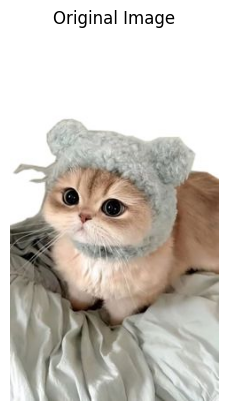

In [20]:
image = cv2.imread('image.jpg')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print("Original image shape:", image.shape)
plt.imshow(image_rgb)
plt.title("Original Image")
plt.axis('off')
plt.show()

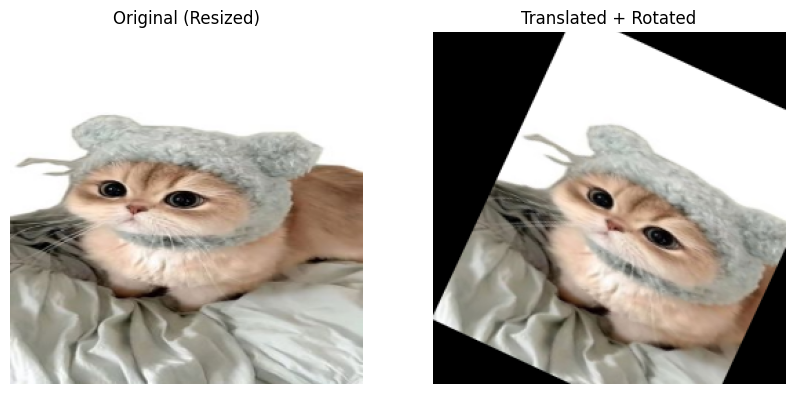

In [21]:
#resizing
resized = cv2.resize(image_rgb, (256, 256))

#translation
dx, dy = 45, 10
M_translation = np.float32([[1, 0, dx], [0, 1, dy]])
translated = cv2.warpAffine(resized, M_translation, (256, 256))

#rotation
center = (128, 128)  # центр изображения 256x256
angle = -25
scale = 1.0
M_rotation = cv2.getRotationMatrix2D(center, angle, scale)
rotated = cv2.warpAffine(translated, M_rotation, (256, 256))

#results
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(resized)
axes[0].set_title("Original (Resized)")
axes[0].axis('off')
axes[1].imshow(rotated)
axes[1].set_title("Translated + Rotated")
axes[1].axis('off')
plt.show()

In [22]:
x, y = 80, 150
original_pixel = resized[y, x]  # (y, x) в numpy
transformed_pixel = rotated[y, x]

print(f"Original pixel at ({x}, {y}): {original_pixel}")
print(f"Transformed pixel at ({x}, {y}): {transformed_pixel}")

Original pixel at (80, 150): [224 211 197]
Transformed pixel at (80, 150): [91 81 72]


In [23]:
print("Translation matrix M:")
print(M_translation)
print("\nRotation matrix M:")
print(M_rotation)

# Исходные точки
points = np.array([[20, 20], [128, 128], [240, 200]], dtype=np.float32)
points = points.reshape(-1, 1, 2)

# Преобразование точек
points_translated = cv2.transform(points, M_translation)
points_rotated = cv2.transform(points_translated, M_rotation)

print("\nPoints before transformation:")
print(points.reshape(-1, 2))
print("\nPoints after translation:")
print(points_translated.reshape(-1, 2))
print("\nPoints after rotation:")
print(points_rotated.reshape(-1, 2))



Translation matrix M:
[[ 1.  0. 45.]
 [ 0.  1. 10.]]

Rotation matrix M:
[[  0.90630779  -0.42261826  66.08774076]
 [  0.42261826   0.90630779 -42.10253424]]

Points before transformation:
[[ 20.  20.]
 [128. 128.]
 [240. 200.]]

Points after translation:
[[ 65.  30.]
 [173. 138.]
 [285. 210.]]

Points after rotation:
[[112.3192    12.556885]
 [164.55768  156.0809  ]
 [235.63562  268.6683  ]]


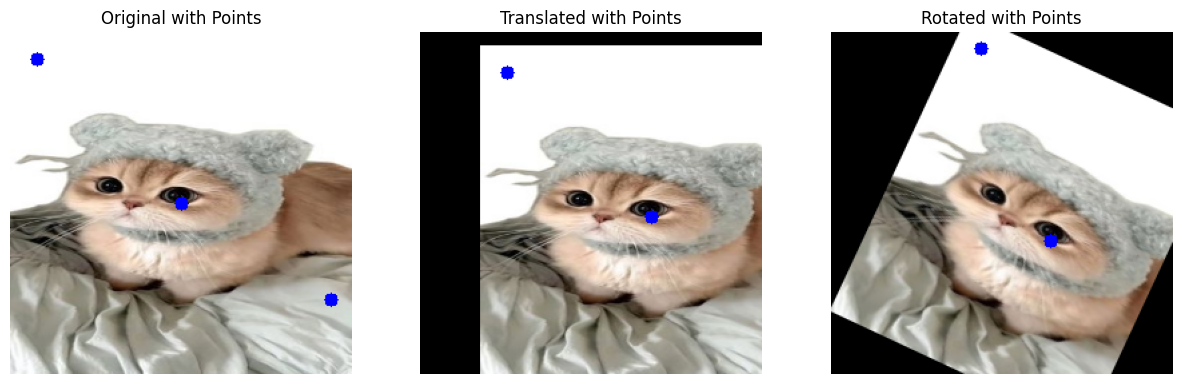

In [24]:
# Make copies of the images to draw on
resized_copy = resized.copy()
translated_copy = translated.copy()
rotated_copy = rotated.copy()

# Draw original points on the resized image
for (x, y) in points.reshape(-1, 2).astype(int):
    cv2.circle(resized_copy, (x, y), 5, (0, 0, 255), -1) # Red circles

# Draw translated points on the translated image
for (x, y) in points_translated.reshape(-1, 2).astype(int):
    cv2.circle(translated_copy, (x, y), 5, (0, 0, 255), -1)

# Draw rotated points on the rotated image
for (x, y) in points_rotated.reshape(-1, 2).astype(int):
    cv2.circle(rotated_copy, (x, y), 5, (0, 0, 255), -1)

# Display the images with drawn points
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(resized_copy)
axes[0].set_title("Original with Points")
axes[0].axis('off')
axes[1].imshow(translated_copy)
axes[1].set_title("Translated with Points")
axes[1].axis('off')
axes[2].imshow(rotated_copy)
axes[2].set_title("Rotated with Points")
axes[2].axis('off')
plt.show()

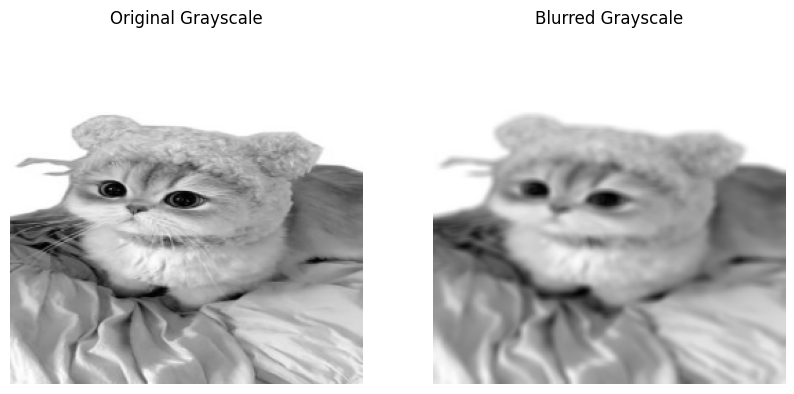

Original grayscale patch (100:105, 100:105):
[[128 125  92  84  81]
 [115 100  82  82  89]
 [107  83  79  88 117]
 [101  80  87 100 123]
 [ 88  86  99 113 116]]

Blurred grayscale patch (100:105, 100:105):
[[125 115 108 102 100]
 [116 107 102  99 101]
 [107 100  98  98 102]
 [ 99  96  97 101 108]
 [ 97  96 100 106 114]]


In [25]:
#blurring 5x5
kernel_blur = np.ones((5, 5), dtype=np.float32) / 25
blurred = cv2.filter2D(resized, -1, kernel_blur)

#grayscale
gray_original = cv2.cvtColor(resized, cv2.COLOR_RGB2GRAY)
gray_blurred = cv2.cvtColor(blurred, cv2.COLOR_RGB2GRAY)


fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray_original, cmap='gray')
axes[0].set_title("Original Grayscale")
axes[0].axis('off')
axes[1].imshow(gray_blurred, cmap='gray')
axes[1].set_title("Blurred Grayscale")
axes[1].axis('off')
plt.show()

#Патч 5x5
print("Original grayscale patch (100:105, 100:105):")
print(gray_original[100:105, 100:105])
print("\nBlurred grayscale patch (100:105, 100:105):")
print(gray_blurred[100:105, 100:105])

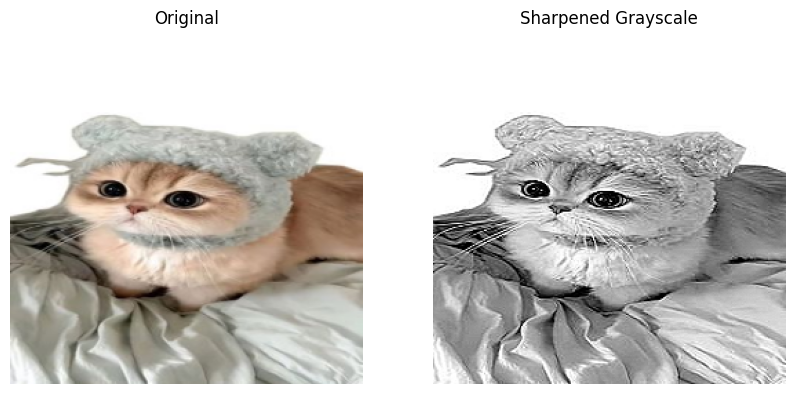

Sharpened grayscale patch (100:105, 100:105):
[[119 167  52  54  44]
 [114  95  55  67  70]
 [124  50  55  63 156]
 [116  43  77  90 160]
 [ 88  92 111 117 106]]


In [26]:
#sharpenning
kernel_sharpen = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]], dtype=np.float32)
sharpened = cv2.filter2D(resized, -1, kernel_sharpen)
gray_sharpened = cv2.cvtColor(sharpened, cv2.COLOR_RGB2GRAY)


fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(resized)
axes[0].set_title("Original")
axes[0].axis('off')
axes[1].imshow(gray_sharpened, cmap='gray')
axes[1].set_title("Sharpened Grayscale")
axes[1].axis('off')
plt.show()

#Патч 5x5
print("Sharpened grayscale patch (100:105, 100:105):")
print(gray_sharpened[100:105, 100:105])

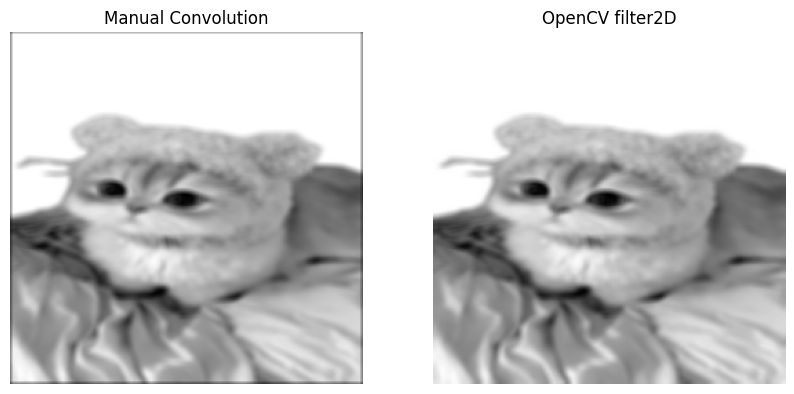

Manual convolution patch (100:105, 100:105):
[[124 115 107 102  99]
 [116 107 101  99 100]
 [107 100  97  98 101]
 [ 99  96  97 101 107]
 [ 96  95 100 106 114]]

OpenCV convolution patch (100:105, 100:105):
[[125 115 108 102 100]
 [116 107 102  99 100]
 [107 100  98  98 102]
 [ 99  96  97 101 108]
 [ 97  96 100 106 114]]


In [27]:
def manual_convolution(image, kernel):
    h, w = image.shape
    kh, kw = kernel.shape
    pad_h, pad_w = kh // 2, kw // 2
    padded = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant')
    output = np.zeros_like(image, dtype=np.float32)
    for i in range(h):
        for j in range(w):
            output[i, j] = np.sum(padded[i:i+kh, j:j+kw] * kernel)
    return output

#manual blur
manual_blur = manual_convolution(gray_original, kernel_blur)
cv_blur = cv2.filter2D(gray_original, -1, kernel_blur)


fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(manual_blur, cmap='gray')
axes[0].set_title("Manual Convolution")
axes[0].axis('off')
axes[1].imshow(cv_blur, cmap='gray')
axes[1].set_title("OpenCV filter2D")
axes[1].axis('off')
plt.show()

#comparing patches
print("Manual convolution patch (100:105, 100:105):")
print(manual_blur[100:105, 100:105].astype(np.uint8))
print("\nOpenCV convolution patch (100:105, 100:105):")
print(cv_blur[100:105, 100:105])

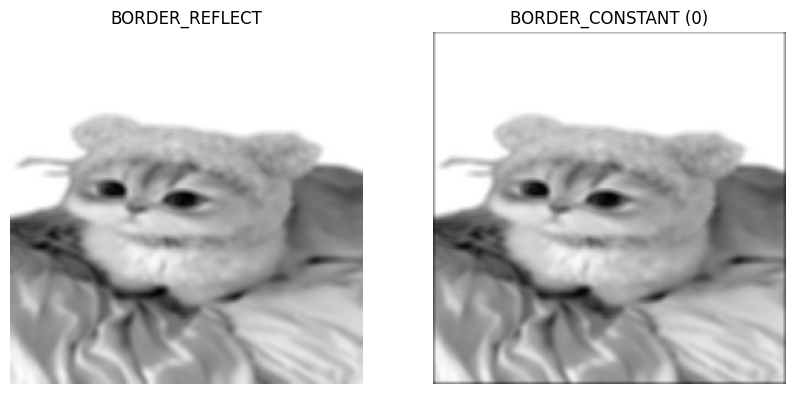

BORDER_REFLECT patch (0:5, 0:5):
[[255 255 255 255 255]
 [255 255 255 255 255]
 [255 255 255 255 255]
 [255 255 255 255 255]
 [255 255 255 255 255]]

BORDER_CONSTANT patch (0:5, 0:5):
[[ 92 122 153 153 153]
 [122 163 204 204 204]
 [153 204 255 255 255]
 [153 204 255 255 255]
 [153 204 255 255 255]]


In [28]:
#different types of egges
blur_reflect = cv2.filter2D(gray_original, -1, kernel_blur, borderType=cv2.BORDER_REFLECT)
blur_constant = cv2.filter2D(gray_original, -1, kernel_blur, borderType=cv2.BORDER_CONSTANT)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(blur_reflect, cmap='gray')
axes[0].set_title("BORDER_REFLECT")
axes[0].axis('off')
axes[1].imshow(blur_constant, cmap='gray')
axes[1].set_title("BORDER_CONSTANT (0)")
axes[1].axis('off')
plt.show()

# Патч в углу
print("BORDER_REFLECT patch (0:5, 0:5):")
print(blur_reflect[0:5, 0:5])
print("\nBORDER_CONSTANT patch (0:5, 0:5):")
print(blur_constant[0:5, 0:5])

Input shape: (256, 256)
Output shape: (128, 128)

Input block (100:104, 100:104):
[[125 115 108 102]
 [116 107 102  99]
 [107 100  98  98]
 [ 99  96  97 101]]

Output block (50:52, 50:52):
[[125. 108.]
 [107. 101.]]


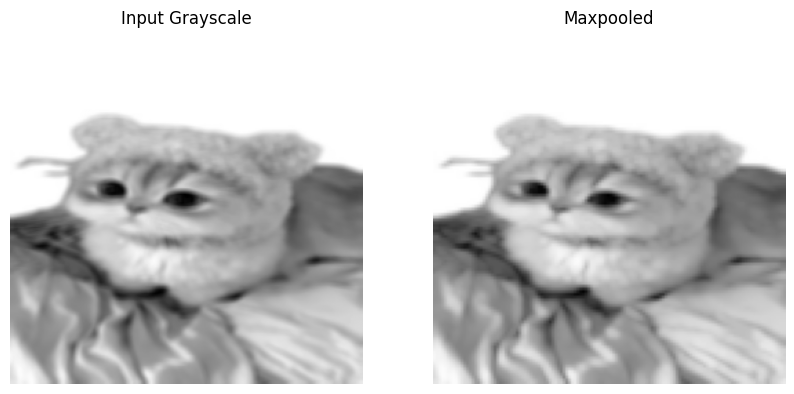

In [29]:
def maxpool2d(image, pool_size=2, stride=2):
    h, w = image.shape
    out_h = (h - pool_size) // stride + 1
    out_w = (w - pool_size) // stride + 1
    pooled = np.zeros((out_h, out_w))
    for i in range(0, out_h):
        for j in range(0, out_w):
            window = image[i*stride:i*stride+pool_size, j*stride:j*stride+pool_size]
            pooled[i, j] = np.max(window)
    return pooled

pooled = maxpool2d(gray_blurred, pool_size=2, stride=2)
print("Input shape:", gray_blurred.shape)
print("Output shape:", pooled.shape)

print("\nInput block (100:104, 100:104):")
print(gray_blurred[100:104, 100:104])
print("\nOutput block (50:52, 50:52):")
print(pooled[50:52, 50:52])

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray_blurred, cmap='gray')
axes[0].set_title("Input Grayscale")
axes[0].axis('off')
axes[1].imshow(pooled, cmap='gray')
axes[1].set_title("Maxpooled")
axes[1].axis('off')
plt.show()

In [30]:
input_patch = np.array([[2, 0, 1],
                        [3, 1, 2],
                        [0, 4, 1]], dtype=np.float32)

kernel = np.ones((3, 3), dtype=np.float32)  # все 1

print("Manual convolution calculation:")
output = 0
for i in range(3):
    for j in range(3):
        val = input_patch[i, j] * kernel[i, j]
        print(f"  {input_patch[i, j]} * {kernel[i, j]} = {val}")
        output += val
print(f"\nSum (output value): {output}")

Manual convolution calculation:
  2.0 * 1.0 = 2.0
  0.0 * 1.0 = 0.0
  1.0 * 1.0 = 1.0
  3.0 * 1.0 = 3.0
  1.0 * 1.0 = 1.0
  2.0 * 1.0 = 2.0
  0.0 * 1.0 = 0.0
  4.0 * 1.0 = 4.0
  1.0 * 1.0 = 1.0

Sum (output value): 14.0


In [31]:
input_matrix = np.array([[2, 4, 1, 0],
                         [3, 1, 5, 2],
                         [0, 6, 2, 7],
                         [4, 1, 3, 5]], dtype=np.float32)

print("Input matrix:")
print(input_matrix)

print("\nMaxpooling with 2x2 window, stride 2:")
output = np.zeros((2, 2))
for i in range(0, 4, 2):
    for j in range(0, 4, 2):
        window = input_matrix[i:i+2, j:j+2]
        max_val = np.max(window)
        output[i//2, j//2] = max_val
        print(f"Window at ({i},{j}):\n{window}")
        print(f"Max: {max_val}\n")

print("Output matrix:")
print(output)

Input matrix:
[[2. 4. 1. 0.]
 [3. 1. 5. 2.]
 [0. 6. 2. 7.]
 [4. 1. 3. 5.]]

Maxpooling with 2x2 window, stride 2:
Window at (0,0):
[[2. 4.]
 [3. 1.]]
Max: 4.0

Window at (0,2):
[[1. 0.]
 [5. 2.]]
Max: 5.0

Window at (2,0):
[[0. 6.]
 [4. 1.]]
Max: 6.0

Window at (2,2):
[[2. 7.]
 [3. 5.]]
Max: 7.0

Output matrix:
[[4. 5.]
 [6. 7.]]
